# Transit Modeling with batman and Limb Darkening from ldtk

This notebook builds on the cleaned and detrended TESS and TASTE light curves to model the transit of the exoplanet. The goal is to generate theoretical transit light curves using the `batman` package and compare them with the observed data. We also compute realistic limb darkening coefficients for the Sloan r' and TESS passbands using the `ldtk` package, which provides Monte Carlo sampling from stellar atmosphere models.

## Why model transits?
Modeling transits allows us to:
- Verify the consistency of the orbital and physical parameters (period, radius ratio, inclination, etc.) derived from the literature.
- Assess the impact of limb darkening on the transit shape.
- Prepare phase‑folded light curves for further analysis, such as transit timing variations or atmospheric characterization.

## Methods
1. **Limb darkening coefficients**: Using the `ldtk` package and stellar parameters (Teff, log g, metallicity), we generate a set of possible stellar intensity profiles via a Markov chain Monte Carlo (MCMC) approach. These profiles are then used to compute quadratic limb darkening coefficients (u₁, u₂) for each filter. The final coefficients are reported with their uncertainties.

2. **Transit modeling with batman**: For each dataset (TASTE and TESS sectors 43, 44, 45), we initialize a `batman.TransitModel` with the orbital parameters taken from the literature. We then compute the model light curve using the limb darkening coefficients obtained from ldtk.

3. **Visualization**: We plot the observed fluxes together with the best‑fit model light curves to assess the agreement. For the TESS data, we also phase‑fold the time series to highlight the transit shape.

## Output
The notebook produces:
- Printed limb darkening coefficients for both filters with standard deviations.
- High‑quality plots of the observed and modeled light curves for each dataset.
- Phase‑folded plots for the TESS sectors to better visualize the transit.

These outputs will be used to confirm the planetary parameters and provide a foundation for future analysis, such as TTV searches or transmission spectroscopy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pickle
import batman
%matplotlib widget


In [2]:
taste_bjd_tdb = pickle.load(open('/Users/ashaimaalrawhi/Desktop/AstroLab/TASTE_analysis/taste_bjdtdb.p', 'rb'))
differential_allref_normalized = pickle.load(open('/Users/ashaimaalrawhi/Desktop/AstroLab/TASTE_analysis/differential_allref_normalized.p', 'rb'))
differential_allref_normalized_error = pickle.load(open('/Users/ashaimaalrawhi/Desktop/AstroLab/TASTE_analysis/differential_allref_normalized_error.p', 'rb'))

differential_allref =  pickle.load(open('/Users/ashaimaalrawhi/Desktop/AstroLab/TASTE_analysis/differential_allref.p', 'rb'))
differential_allref_error = pickle.load(open('/Users/ashaimaalrawhi/Desktop/AstroLab/TASTE_analysis/differential_allref_error.p', 'rb'))

tess_sector43_dict = pickle.load(open('WASP_TESS_sector43_filter_selected.p', 'rb'))

tess_bjd_tdb_43 = tess_sector43_dict['time']
tess_normalized_flux_43 = tess_sector43_dict['selected_flux']
tess_normalized_flux_error_43 = tess_sector43_dict['selected_flux_error']

In [3]:
tess_sector44_dict = pickle.load(open('WASP_TESS_sector44_filter_selected.p', 'rb'))

tess_bjd_tdb_44 = tess_sector44_dict['time']
tess_normalized_flux_44 = tess_sector44_dict['selected_flux']
tess_normalized_flux_error_44 = tess_sector44_dict['selected_flux_error']

In [4]:
tess_sector45_dict = pickle.load(open('WASP_TESS_sector45_filter_selected.p', 'rb'))

tess_bjd_tdb_45 = tess_sector45_dict['time']
tess_normalized_flux_45 = tess_sector45_dict['selected_flux']
tess_normalized_flux_error_45 = tess_sector45_dict['selected_flux_error']

In [5]:
from ldtk import SVOFilter , LDPSetCreator
SVOFilter.shortcuts

/Users/ashaimaalrawhi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


{'kepler': 'Kepler/Kepler.k',
 'tess': 'TESS/TESS.Red',
 'sdss_g': 'SLOAN/SDSS.g',
 'sdss_r': 'SLOAN/SDSS.r',
 'sdss_i': 'SLOAN/SDSS.i',
 'sdss_z': 'SLOAN/SDSS.z'}

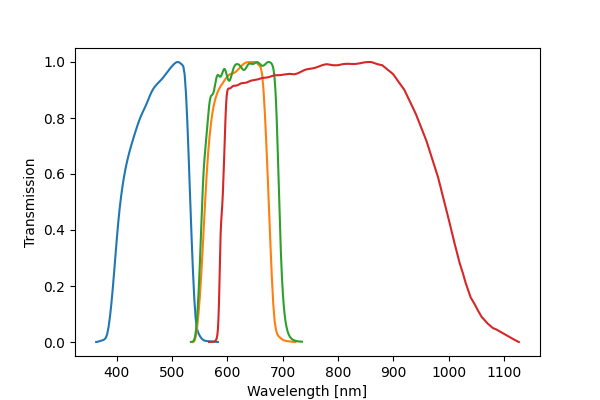

In [6]:
sloan_g = SVOFilter('sdss_g')
sloan_r = SVOFilter('sdss_r')
sloan_rprime = SVOFilter('SLOAN/SDSS.rprime_filter')
tess_filter = SVOFilter('tess')

fig, ax = plt.subplots(figsize=(6,4))
sloan_g.plot(ax=ax)
sloan_r.plot(ax=ax)
sloan_rprime.plot(ax=ax)
tess_filter.plot(ax=ax)
plt.show()


In [7]:
filters = [sloan_r, tess_filter]
sc = LDPSetCreator(teff=(6154, 105), logg=(4.02, 0.08), z=(0.21, 0.10), filters=filters)
ps = sc.create_profiles(nsamples=2000)
ps.resample_linear_z(100)

ps.set_uncertainty_multiplier(10)
qm, qe = ps.coeffs_qd(do_mc=True, n_mc_samples=10000)
chains = np.array(ps._samples['qd'])

In [8]:
print(np.shape(chains))

(2, 10000, 2)


Sloan r LD coefficients: u1 = 0.51 \pm 0.01    u2 = 0.13 \pm 0.03
TESS LD coefficients   : u1 = 0.41 \pm 0.01    u2 = 0.13 \pm 0.03


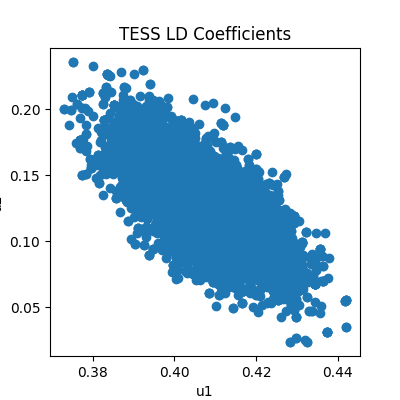

In [9]:
u1_sloan_r_chains = chains[0,:,0]
u2_sloan_r_chains = chains[0,:,1]

u1_tess_chains = chains[1,:,0]
u2_tess_chains = chains[1,:,1]

print('Sloan r LD coefficients: u1 = {0:4.2f} \pm {1:4.2f}    u2 = {2:4.2f} \pm {3:4.2f}'.format(
    np.mean(u1_sloan_r_chains), np.std(u1_sloan_r_chains),  
    np.mean(u2_sloan_r_chains), np.std(u2_sloan_r_chains),
))

print('TESS LD coefficients   : u1 = {0:4.2f} \pm {1:4.2f}    u2 = {2:4.2f} \pm {3:4.2f}'.format(
    np.mean(u1_tess_chains), np.std(u1_tess_chains),  
    np.mean(u2_tess_chains), np.std(u2_tess_chains),
))


plt.figure(figsize=(4,4))
plt.title('TESS LD Coefficients')
plt.xlabel('u1')
plt.ylabel('u2')
plt.scatter(u1_tess_chains, u2_tess_chains)
plt.show()

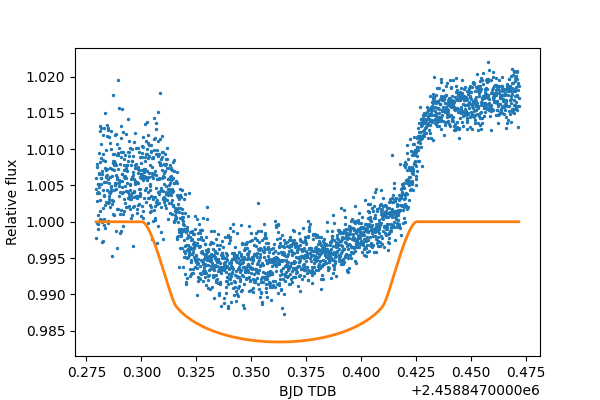

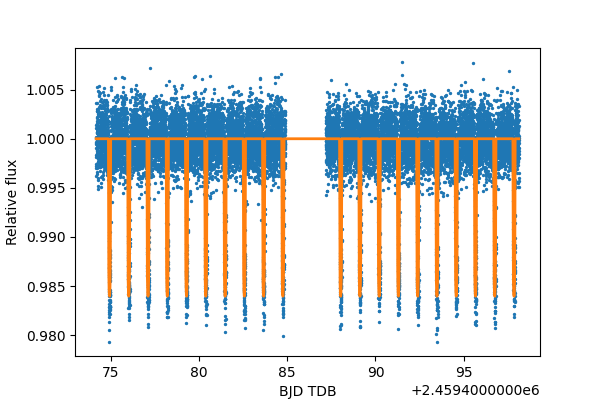

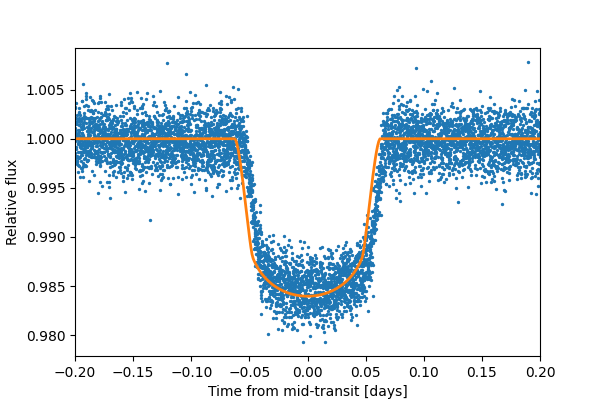

In [10]:
params = batman.TransitParams()
params.t0 =  2458842.997159                     #time of inferior conjunction
params.per = 1.09142030                     #orbital period
params.rp = 0.11785                     #planet radius (in units of stellar radii)
params.a = 3.039                        #semi-major axis (in units of stellar radii)
params.inc =83.37                      #orbital inclination (in degrees)
params.ecc = 0.                      #eccentricity
params.w = 90.                      #longitude of periastron (in degrees)

###TASTE LD
params.u = [0.51, 0.13]             #limb darkening coefficients [u1, u2]
params.limb_dark = "quadratic"       #limb darkening model


m_taste = batman.TransitModel(params, taste_bjd_tdb)    #initializes model
taste_model_flux = m_taste.light_curve(params)          #calculates light curv
plt.figure(figsize=(6,4))
plt.scatter(taste_bjd_tdb, differential_allref_normalized, s=2)

plt.plot(taste_bjd_tdb, taste_model_flux, lw=2, c='C1')
plt.xlabel("BJD TDB")
plt.ylabel("Relative flux")
plt.show()



###TESS LD
params.u = [0.41, 0.13]             #limb darkening coefficients [u1, u2]
params.limb_dark = "quadratic"       #limb darkening model


m_tess_43 = batman.TransitModel(params, tess_bjd_tdb_43)    #initializes model
tess_model_flux_43 =m_tess_43.light_curve(params)          #calculates light curv
plt.figure(figsize=(6,4))
plt.scatter(tess_bjd_tdb_43, tess_normalized_flux_43, s=2)
plt.plot(tess_bjd_tdb_43, tess_model_flux_43, lw=2, c='C1')
plt.xlabel("BJD TDB")
plt.ylabel("Relative flux")
plt.show()

folded_tess_time_43 = (tess_bjd_tdb_43 - params.t0 - params.per/2. ) % params.per - params.per/2. 
folded_range_43 = np.arange(- params.per/2.,  params.per/2., 0.001)

params.t0 = 0.                     #time of inferior conjunction
m_folded_tess_43 = batman.TransitModel(params, folded_range_43)    #initializes model
tess_folded_flux =m_folded_tess_43.light_curve(params)          #calculates light curv
plt.figure(figsize=(6,4))
plt.scatter(folded_tess_time_43, tess_normalized_flux_43, s=2)
plt.plot(folded_range_43, tess_folded_flux, lw=2, c='C1')
plt.xlim(-0.2, 0.2)
plt.xlabel("Time from mid-transit [days]")
plt.ylabel("Relative flux")
plt.show()

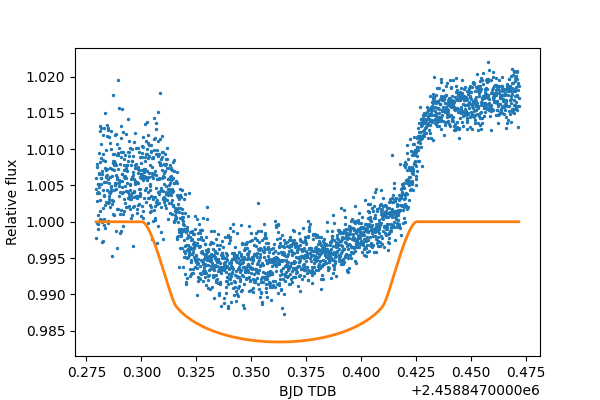

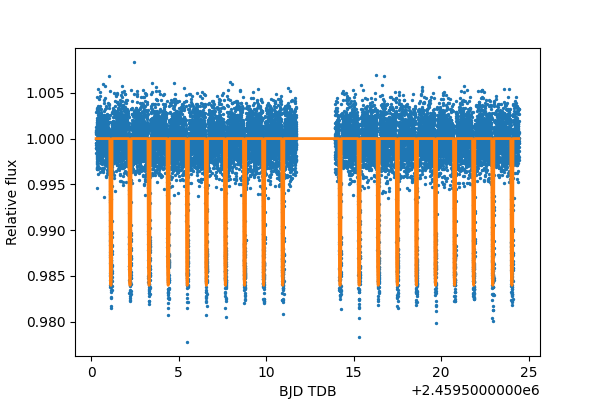

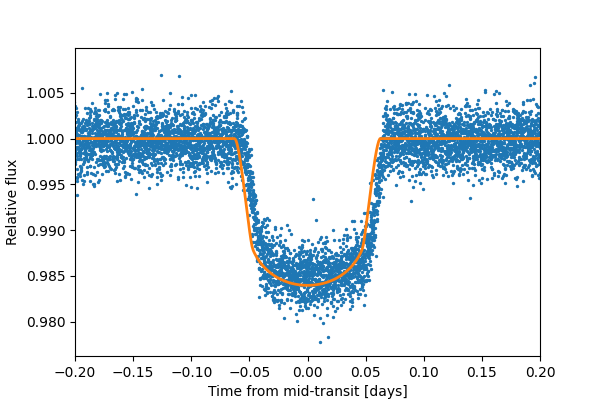

In [11]:
params = batman.TransitParams()
params.t0 =  2458842.997159                     #time of inferior conjunction
params.per = 1.09142030                     #orbital period
params.rp = 0.11785                     #planet radius (in units of stellar radii)
params.a = 3.039                        #semi-major axis (in units of stellar radii)
params.inc =83.37                      #orbital inclination (in degrees)
params.ecc = 0.                      #eccentricity
params.w = 90.                      #longitude of periastron (in degrees)

###TASTE LD
params.u = [0.51, 0.13]             #limb darkening coefficients [u1, u2]
params.limb_dark = "quadratic"       #limb darkening model


m_taste = batman.TransitModel(params, taste_bjd_tdb)    #initializes model
taste_model_flux = m_taste.light_curve(params)          #calculates light curv
plt.figure(figsize=(6,4))
plt.scatter(taste_bjd_tdb, differential_allref_normalized, s=2)

plt.plot(taste_bjd_tdb, taste_model_flux, lw=2, c='C1')
plt.xlabel("BJD TDB")
plt.ylabel("Relative flux")
plt.show()



###TESS LD
params.u = [0.41, 0.13]             #limb darkening coefficients [u1, u2]
params.limb_dark = "quadratic"       #limb darkening model


m_tess_44 = batman.TransitModel(params, tess_bjd_tdb_44)    #initializes model
tess_model_flux_44 =m_tess_44.light_curve(params)          #calculates light curv
plt.figure(figsize=(6,4))
plt.scatter(tess_bjd_tdb_44, tess_normalized_flux_44, s=2)
plt.plot(tess_bjd_tdb_44, tess_model_flux_44, lw=2, c='C1')
plt.xlabel("BJD TDB")
plt.ylabel("Relative flux")
plt.show()

folded_tess_time_44 = (tess_bjd_tdb_44 - params.t0 - params.per/2. ) % params.per - params.per/2. 
folded_range_44 = np.arange(- params.per/2.,  params.per/2., 0.001)

params.t0 = 0.                     #time of inferior conjunction
m_folded_tess_44 = batman.TransitModel(params, folded_range_44)    #initializes model
tess_folded_flux =m_folded_tess_44.light_curve(params)          #calculates light curv
plt.figure(figsize=(6,4))
plt.scatter(folded_tess_time_44, tess_normalized_flux_44, s=2)
plt.plot(folded_range_44, tess_folded_flux, lw=2, c='C1')
plt.xlim(-0.2, 0.2)
plt.xlabel("Time from mid-transit [days]")
plt.ylabel("Relative flux")
plt.show()

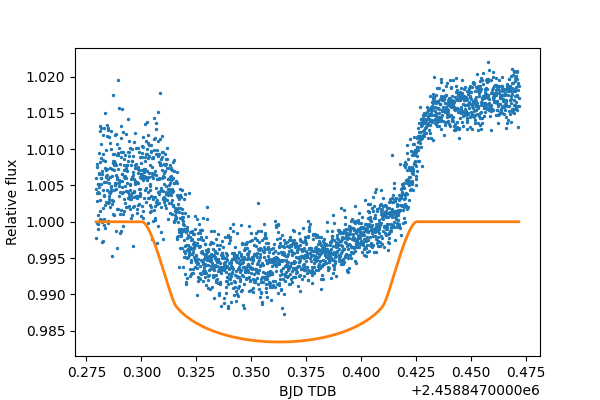

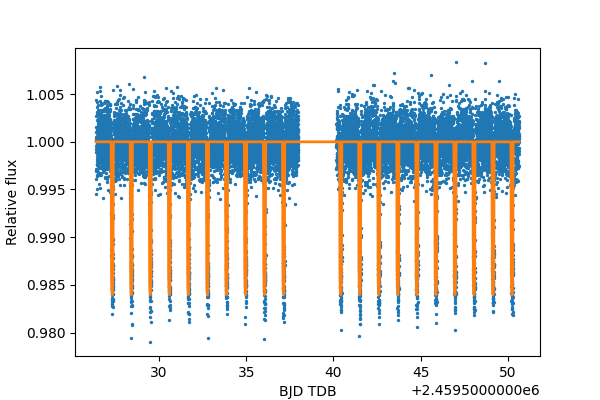

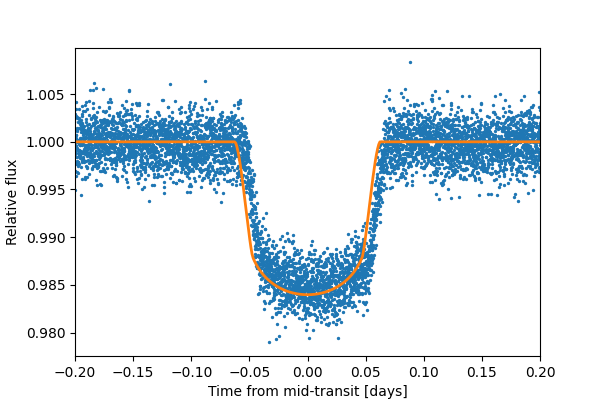

In [12]:
params = batman.TransitParams()
params.t0 =  2458842.997159                     #time of inferior conjunction
params.per = 1.09142030                     #orbital period
params.rp = 0.11785                     #planet radius (in units of stellar radii)
params.a = 3.039                        #semi-major axis (in units of stellar radii)
params.inc =83.37                      #orbital inclination (in degrees)
params.ecc = 0.                      #eccentricity
params.w = 90.                      #longitude of periastron (in degrees)

###TASTE LD
params.u = [0.51, 0.13]             #limb darkening coefficients [u1, u2]
params.limb_dark = "quadratic"       #limb darkening model


m_taste = batman.TransitModel(params, taste_bjd_tdb)    #initializes model
taste_model_flux = m_taste.light_curve(params)          #calculates light curv
plt.figure(figsize=(6,4))
plt.scatter(taste_bjd_tdb, differential_allref_normalized, s=2)

plt.plot(taste_bjd_tdb, taste_model_flux, lw=2, c='C1')
plt.xlabel("BJD TDB")
plt.ylabel("Relative flux")
plt.show()



###TESS LD
params.u = [0.41, 0.13]             #limb darkening coefficients [u1, u2]
params.limb_dark = "quadratic"       #limb darkening model


m_tess_45 = batman.TransitModel(params, tess_bjd_tdb_45)    #initializes model
tess_model_flux_45 =m_tess_45.light_curve(params)          #calculates light curv
plt.figure(figsize=(6,4))
plt.scatter(tess_bjd_tdb_45, tess_normalized_flux_45, s=2)
plt.plot(tess_bjd_tdb_45, tess_model_flux_45, lw=2, c='C1')
plt.xlabel("BJD TDB")
plt.ylabel("Relative flux")
plt.show()

folded_tess_time_45 = (tess_bjd_tdb_45 - params.t0 - params.per/2. ) % params.per - params.per/2. 
folded_range_45 = np.arange(- params.per/2.,  params.per/2., 0.001)

params.t0 = 0.                     #time of inferior conjunction
m_folded_tess_45 = batman.TransitModel(params, folded_range_45)    #initializes model
tess_folded_flux =m_folded_tess_45.light_curve(params)          #calculates light curv
plt.figure(figsize=(6,4))
plt.scatter(folded_tess_time_45, tess_normalized_flux_45, s=2)
plt.plot(folded_range_45, tess_folded_flux, lw=2, c='C1')
plt.xlim(-0.2, 0.2)
plt.xlabel("Time from mid-transit [days]")
plt.ylabel("Relative flux")
plt.show()